In [ ]:
!pip install imbalanced-learn

In [ ]:
import pandas as pd
import nltk
import string
from imblearn.over_sampling import SMOTE

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

In [ ]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download("punkt_tab")
nltk.download("stopwords")


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import MultinomialNB

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
df=pd.read_csv("/content/sms_spam_collection (1).csv")

In [ ]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.describe()

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [ ]:
df.value_counts()

label  message                                                                                                                                 
ham    Sorry, I'll call later                                                                                                                      30
       I cant pick the phone right now. Pls send a message                                                                                         12
       Ok...                                                                                                                                       10
       Okie                                                                                                                                         4
       Your opinion about me? 1. Over 2. Jada 3. Kusruthi 4. Lovable 5. Silent 6. Spl character 7. Not matured 8. Stylish 9. Simple Pls reply..     4
                                                                                                                                                   ..
       I want to tell you how bad I feel that basically the only times I text you lately are when I need drugs                                      1
       I want to tel u one thing u should not mistake me k THIS IS THE MESSAGE THAT YOU SENT:)                                                      1
       I want to show you the world, princess :) how about europe?                                                                                  1
       I want to send something that can sell fast.  &lt;#&gt; k is not easy money.                                                                 1
       I was just callin to say hi. Take care bruv!                                                                                                 1
Name: count, Length: 5169, dtype: int64

In [ ]:
df.tail(5)

,label,message
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [ ]:
df["label"].value_counts()

,count
label,
ham,4825
spam,747


In [ ]:
def clean_text(text):
  text=text.lower()
  text=text.translate(str.maketrans("","",string.punctuation))

  words=word_tokenize(text)
  filtered_words=[]

  for word in words:
    if word not in stopwords.words("english"):
      filtered_words.append(word)
  return " ".join(filtered_words)

In [ ]:
df["cleaned_message"]=df["message"].apply(clean_text)

In [ ]:
display(df)

,label,message,cleaned_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,2nd time tried 2 contact u u £750 pound prize ...
5568,ham,Will ü b going to esplanade fr home?,ü b going esplanade fr home
5569,ham,"Pity, * was in mood for that. So...any other s...",pity mood soany suggestions
5570,ham,The guy did some bitching but I acted like i'd...,guy bitching acted like id interested buying s...


In [ ]:
vectorizer=TfidfVectorizer()
X=vectorizer.fit_transform(df['cleaned_message'])
y=df["label"]

In [ ]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X_resampled,y_resampled,train_size=0.2,random_state=42)

In [ ]:
model=MultinomialNB()
model.fit(X_train,y_train)

MultinomialNB()

In [ ]:
pred=model.predict(X_test)

In [ ]:
accuracy=accuracy_score(y_test,pred)

In [ ]:
print("Accuracy:",accuracy)

Accuracy: 0.9705958549222798


In [ ]:
compared_df=pd.DataFrame({"actual_values":y_test,"predicted_values":pred})

In [ ]:
compared_df.value_counts()

actual_values  predicted_values
spam           spam                3829
ham            ham                 3664
               spam                 182
spam           ham                   45
Name: count, dtype: int64

In [ ]:
confusion_mat=confusion_matrix(y_test,pred)
print(confusion_mat)

[[3664  182]
 [  45 3829]]


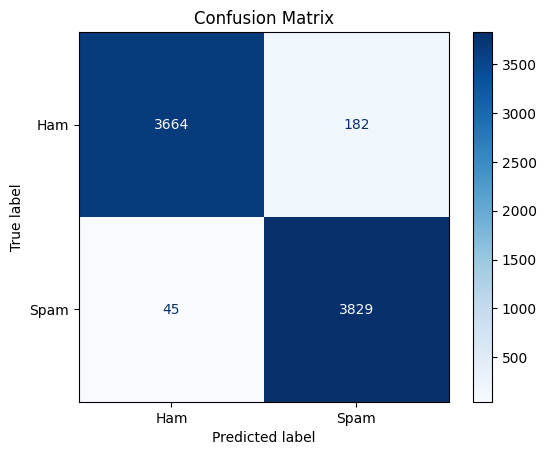

In [ ]:
disp=ConfusionMatrixDisplay(confusion_matrix=confusion_mat,display_labels=["Ham","Spam"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
test_message=["Congratulations! You’ve won a free iPhone. Click here to claim your prize now.",

"URGENT: Your account will be suspended unless you verify your details immediately.",

"Get cheap loans at 0% interest. Apply today!",

"You’ve been selected for a $500 gift card. Reply YES to claim.",

"Exclusive deal: Buy 1 get 1 FREE on all products. Limited time offer!",

"Hey, are we still meeting at 6 pm for dinner?",

"Don’t forget to bring your notebook to class tomorrow.",

"Can you send me the project report by evening?",

"Happy Birthday! Wishing you a wonderful year ahead.",

"I’ll call you once I reach home."
              ]

In [ ]:
cleaned=[clean_text(msg) for msg in test_message]

In [ ]:
X_new_test=vectorizer.transform(cleaned)

In [ ]:
predictions=model.predict(X_new_test)

In [ ]:
print(predictions)

['spam' 'spam' 'spam' 'spam' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham']


In [ ]:
def predict_message(msg):
    cleaned = clean_text(msg)
    X_test = vectorizer.transform([cleaned])
    prediction = model.predict(X_test)[0]   # get single value
    return f"Prediction: {str(prediction).upper()}"


# --- Gradio Interface ---
iface = gr.Interface(
    fn=predict_message,
    inputs=gr.Textbox(lines=3, placeholder="Enter your message here..."),
    outputs="text",
    title="📩 Spam Message Classifier",
    description="Type a message and see if it's Spam or Ham."
)

iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://01b952a8ac9e3ee8e9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
